# Category Intelligence — Retail Product Performance EDA
## Individual Notebook — Sanapalli Vikas

**Team: Batch_12 | Member: Mem4 | Role: Business Synthesis Analyst**

**Calibo AI Academy · Phase 1 · Mini Use Case 01 · Path 2 — KLU Batch**

| | |
|---|---|
| **Team** | Batch_12 |
| **Member** | Sanapalli Vikas |
| **Role** | Business Synthesis Analyst |
| **Sections owned** | Step 6.6 Category Manager Briefing |

This notebook pulls the four strands of the team analysis into a single position the Category Manager can defend in the supplier review. Every figure quoted in the briefing is re-derived below from the dataset.

**Dataset:** `MUC01_Retail_Sales_Dataset.csv` — place it in the same folder as this notebook.
All figures here are calculated from that file and match the shared team notebook exactly.

*Role note: the assignment brief defines roles for teams of two or three. This team has four members,
so this allocation of the six required steps is our own internal split, not a structure prescribed by
the brief.*

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ---- House chart style: one palette and one labelling convention for the whole notebook ----
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 6),
    "figure.dpi": 110,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

# Fixed category colours so every chart in the notebook reads the same way
CATEGORY_COLOURS = {
    "Electronics":    "#1f4e79",
    "Apparel":        "#c0504d",
    "Grocery":        "#4f8a3d",
    "Home & Kitchen": "#e08a1e",
    "Personal Care":  "#7b5ea7",
}
ACCENT = "#1f4e79"

def inr(x, decimals=2):
    """Format a rupee amount in business-readable units (Cr / L / plain)."""
    if abs(x) >= 1e7:
        return f"\u20b9{x/1e7:,.{decimals}f} Cr"
    if abs(x) >= 1e5:
        return f"\u20b9{x/1e5:,.{decimals}f} L"
    return f"\u20b9{x:,.0f}"

def rupee_axis(ax, scale=1e6, suffix=" Mn", decimals=1):
    """Apply rupee formatting to the y-axis of a chart."""
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"\u20b9{v/scale:,.{decimals}f}{suffix}")
    )

print("Libraries loaded. Chart style set for the whole notebook.")

Libraries loaded. Chart style set for the whole notebook.


## Load the Dataset and Prepare Shared Fields

The same load-and-prepare step used in the team notebook, so this notebook runs standalone and
reproduces identical figures.

In [2]:
df = pd.read_csv("MUC01_Retail_Sales_Dataset.csv")

df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")
df["month_label"] = df["date"].dt.strftime("%b %Y")
df["day_of_week"] = df["date"].dt.day_name()

cat_mix = (df.groupby("category")
             .agg(Transactions=("transaction_id", "count"),
                  Units=("units_sold", "sum"),
                  Revenue=("revenue", "sum"))
             .sort_values("Revenue", ascending=False))
cat_mix["Revenue share %"] = (cat_mix["Revenue"] / cat_mix["Revenue"].sum() * 100).round(1)

monthly_category = (df.pivot_table(index="month", columns="category",
                                   values="revenue", aggfunc="sum").sort_index())
MONTH_ORDER = [p.strftime("%b %Y") for p in monthly_category.index]

print("Rows, Columns    :", df.shape)
print("Date range       :", df["date"].min().date(), "to", df["date"].max().date())
print("Categories       :", df["category"].nunique(), "| Products:", df["product_name"].nunique())
print("Null values      :", int(df.isnull().sum().sum()),
      "| Duplicate transaction IDs:", int(df["transaction_id"].duplicated().sum()))
print("Total revenue    :", inr(df["revenue"].sum()))

Rows, Columns    : (107836, 13)
Date range       : 2026-01-01 to 2026-06-30
Categories       : 5 | Products: 25
Null values      : 0 | Duplicate transaction IDs: 0
Total revenue    : ₹45.98 Cr


## Inputs to the Briefing

**Owner: Sanapalli Vikas — Business Synthesis Analyst (Member 4)**

The briefing is only as good as the figures behind it, so this notebook re-derives the four inputs it
rests on directly from the dataset rather than quoting them from a teammate's notebook. Each block
below reproduces the headline numbers from one section of the team analysis, and the figures match
the shared team notebook exactly.

### Input 1 — Category revenue trend (from Team Member 1, Step 6.2)

Which categories are growing, which are declining, and by how much.

In [3]:
trend = pd.DataFrame({
    "Jan 2026 revenue": monthly_category.iloc[0],
    "Jun 2026 revenue": monthly_category.iloc[-1],
})
trend["Change (\u20b9)"] = trend["Jun 2026 revenue"] - trend["Jan 2026 revenue"]
trend["Change %"] = (trend["Change (\u20b9)"] / trend["Jan 2026 revenue"] * 100).round(2)
trend = trend.sort_values("Change %")

print("CATEGORY CHANGE, JANUARY vs JUNE 2026")
print(trend.round(2).to_string())

chain_first, chain_last = monthly_category.sum(axis=1).iloc[0], monthly_category.sum(axis=1).iloc[-1]
print(f"\nWhole chain: {inr(chain_first)} -> {inr(chain_last)} "
      f"({(chain_last/chain_first-1)*100:+.1f}%)")
print("Investment case :", trend.index[-1], f"({trend['Change %'].iloc[-1]:+.2f}%)")
print("Challenge case  :", trend.index[0], f"({trend['Change %'].iloc[0]:+.2f}%, "
      f"{inr(trend['Change (\u20b9)'].iloc[0])}, "
      f"{cat_mix.loc[trend.index[0], 'Revenue share %']}% of chain revenue)")

CATEGORY CHANGE, JANUARY vs JUNE 2026
                Jan 2026 revenue  Jun 2026 revenue   Change (₹)  Change %
category                                                                 
Electronics          45686596.63       29686824.81 -15999771.82    -35.02
Home & Kitchen       15130871.54       12333283.07  -2797588.47    -18.49
Grocery               7307011.34        7047719.23   -259292.11     -3.55
Personal Care         6593734.81        6737354.12    143619.31      2.18
Apparel              10049916.78       13476952.88   3427036.10     34.10

Whole chain: ₹8.48 Cr -> ₹6.93 Cr (-18.3%)
Investment case : Apparel (+34.10%)
Challenge case  : Electronics (-35.02%, ₹-1.60 Cr, 49.3% of chain revenue)


### Input 2 — Product-level evidence (from Team Member 2, Step 6.3)

The specific product figures to quote when the challenge is made.

In [4]:
CHALLENGE_CAT = trend.index[0]          # the steepest-declining category, calculated above

product_rev = (df.groupby(["category", "product_name"])["revenue"].sum()
                 .reset_index().sort_values("revenue", ascending=False))
challenge_products = product_rev[product_rev["category"] == CHALLENGE_CAT]

print(f"{CHALLENGE_CAT.upper()} - TOTAL REVENUE BY PRODUCT (Jan-Jun 2026)")
for _, r in challenge_products.iterrows():
    print(f"  {r['product_name']:<14} {inr(r['revenue'])}")
print(f"\nWeakest product: {challenge_products.iloc[-1]['product_name']} "
      f"({inr(challenge_products.iloc[-1]['revenue'])})")

monthly_products = (df[df["category"] == CHALLENGE_CAT]
                    .pivot_table(index="month", columns="product_name",
                                 values="revenue", aggfunc="sum"))
prod_change = ((monthly_products.iloc[-1] - monthly_products.iloc[0])
               / monthly_products.iloc[0] * 100).round(1).sort_values()
print(f"\n{CHALLENGE_CAT} Jan-Jun change by product (%):")
print(prod_change.to_string())

sharpest = prod_change.index[0]
print(f"\nSharpest decline: {sharpest} "
      f"{inr(monthly_products[sharpest].iloc[0])} -> {inr(monthly_products[sharpest].iloc[-1])} "
      f"({prod_change.iloc[0]:+.1f}%)")

vol = df[df["category"] == CHALLENGE_CAT].groupby("month").agg(
    transactions=("transaction_id", "count"), avg_unit_price=("unit_price", "mean"))
print(f"\n{CHALLENGE_CAT} monthly transactions and average unit price:")
print(vol.round(0).to_string())
print(f"Transactions lost per month: {int(vol['transactions'].iloc[0] - vol['transactions'].iloc[-1])}")

ELECTRONICS - TOTAL REVENUE BY PRODUCT (Jan-Jun 2026)
  Headphones     ₹4.77 Cr
  Laptop         ₹4.66 Cr
  Mobile Phone   ₹4.57 Cr
  Tablet         ₹4.47 Cr
  Smart TV       ₹4.19 Cr

Weakest product: Smart TV (₹4.19 Cr)

Electronics Jan-Jun change by product (%):
product_name
Mobile Phone   -57.1
Tablet         -40.9
Laptop         -30.7
Smart TV       -21.9
Headphones     -20.3

Sharpest decline: Mobile Phone ₹98.03 L -> ₹42.10 L (-57.1%)

Electronics monthly transactions and average unit price:
         transactions  avg_unit_price
month                                
2026-01           790         24183.0
2026-02           693         23406.0
2026-03           729         23421.0
2026-04           652         23181.0
2026-05           625         22955.0
2026-06           526         23659.0
Transactions lost per month: 264


### Input 3 — Discount effectiveness (from Team Member 3, Step 6.4)

The finding to put to every supplier, and the limit on what it can prove.

In [5]:
BRACKETS = ["0%", "5%", "10%", "15%", "20%", "25%+"]
df["discount_bracket"] = pd.cut(df["discount_pct"],
                                bins=[-0.01, 0, 5, 10, 15, 20, 100], labels=BRACKETS)

discount_summary = (df.groupby("discount_bracket", observed=False)
                      .agg(transactions=("transaction_id", "count"),
                           avg_revenue_per_transaction=("revenue", "mean"),
                           avg_units_sold=("units_sold", "mean")))

print("DISCOUNT BRACKET SUMMARY")
print("Discount levels present in the data:", sorted(df["discount_pct"].unique()))
print("The 25%+ bracket has 0 observations - nothing is estimated for it.\n")
print(discount_summary.round(2).to_string())

full_price = discount_summary.loc["0%", "avg_revenue_per_transaction"]
deepest = discount_summary.loc["20%", "avg_revenue_per_transaction"]
print(f"\nRevenue per transaction, 0% vs 20%: {inr(full_price)} -> {inr(deepest)} "
      f"({(deepest/full_price-1)*100:.1f}%)")
print("Average units sold range across brackets: "
      f"{discount_summary['avg_units_sold'].min():.2f} to {discount_summary['avg_units_sold'].max():.2f}")

foregone = (df["units_sold"] * df["unit_price"]).sum() - df["revenue"].sum()
disc_txns = int((df["discount_pct"] > 0).sum())
print(f"Discounted transactions: {disc_txns:,} of {len(df):,} ({disc_txns/len(df)*100:.1f}%)")
print("Gap between list value and realised revenue:", inr(foregone))
print("\nNOTE: the dataset has no cost, COGS or margin column, so margin impact cannot be measured.")

DISCOUNT BRACKET SUMMARY
Discount levels present in the data: [np.int64(0), np.int64(5), np.int64(10), np.int64(15), np.int64(20)]
The 25%+ bracket has 0 observations - nothing is estimated for it.

                  transactions  avg_revenue_per_transaction  avg_units_sold
discount_bracket                                                           
0%                       36033                      4685.65            2.59
5%                       23922                      4303.73            2.59
10%                      23810                      4005.55            2.57
15%                      11935                      4069.16            2.60
20%                      12136                      3631.73            2.58
25%+                         0                          NaN             NaN

Revenue per transaction, 0% vs 20%: ₹4,686 -> ₹3,632 (-22.5%)
Average units sold range across brackets: 2.57 to 2.60
Discounted transactions: 71,803 of 107,836 (66.6%)
Gap between list value a

### Input 4 — Timing patterns (from Team Member 3, Step 6.5)

When to place the promotional weight the briefing recommends.

In [6]:
DAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily_totals = df.groupby("date", as_index=False)["revenue"].sum()
daily_totals["day_of_week"] = daily_totals["date"].dt.day_name()
dow_chain = daily_totals.groupby("day_of_week")["revenue"].mean().reindex(DAY_ORDER)

print("AVERAGE DAILY REVENUE BY DAY OF WEEK - WHOLE CHAIN")
for d in DAY_ORDER:
    print(f"  {d:<10} {inr(dow_chain[d])}")

weekend = daily_totals["day_of_week"].isin(["Saturday", "Sunday"])
uplift = (daily_totals.loc[weekend, "revenue"].mean()
          / daily_totals.loc[~weekend, "revenue"].mean() - 1) * 100
print(f"\nBest day : {dow_chain.idxmax()} ({inr(dow_chain.max())})")
print(f"Worst day: {dow_chain.idxmin()} ({inr(dow_chain.min())})")
print(f"Weekend uplift over the average weekday: {uplift:.1f}%")

focus_daily = (df[df["category"] == CHALLENGE_CAT]
               .groupby("date", as_index=False)["revenue"].sum())
focus_daily["day_of_week"] = focus_daily["date"].dt.day_name()
focus_dow = focus_daily.groupby("day_of_week")["revenue"].mean().reindex(DAY_ORDER)

shape = pd.DataFrame({
    "Chain index": (dow_chain / dow_chain.mean() * 100).round(1),
    f"{CHALLENGE_CAT} index": (focus_dow / focus_dow.mean() * 100).round(1),
})
print(f"\nDAY-OF-WEEK SHAPE, CHAIN vs {CHALLENGE_CAT.upper()} (100 = that group's average day)")
print(shape.to_string())

AVERAGE DAILY REVENUE BY DAY OF WEEK - WHOLE CHAIN
  Monday     ₹20.12 L
  Tuesday    ₹20.54 L
  Wednesday  ₹22.28 L
  Thursday   ₹22.45 L
  Friday     ₹26.24 L
  Saturday   ₹35.24 L
  Sunday     ₹30.83 L

Best day : Saturday (₹35.24 L)
Worst day: Monday (₹20.12 L)
Weekend uplift over the average weekday: 48.0%

DAY-OF-WEEK SHAPE, CHAIN vs ELECTRONICS (100 = that group's average day)
             Chain index  Electronics index
day_of_week                                
Monday              79.3               77.6
Tuesday             80.9               78.0
Wednesday           87.8               88.9
Thursday            88.5               84.9
Friday             103.3              103.2
Saturday           138.8              142.8
Sunday             121.5              124.6


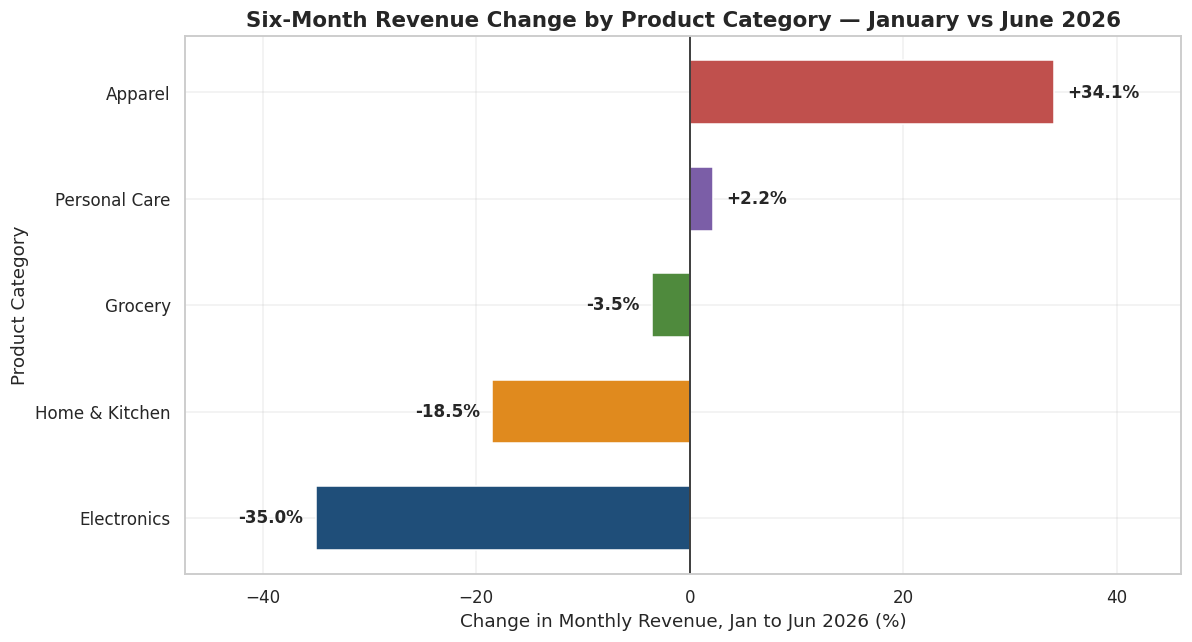

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
ordered = trend.sort_values("Change %")
bar_colours = [CATEGORY_COLOURS[c] for c in ordered.index]
bars = ax.barh(ordered.index, ordered["Change %"], color=bar_colours, edgecolor="white", height=0.6)

for b, v in zip(bars, ordered["Change %"]):
    ax.text(v + (1.2 if v >= 0 else -1.2), b.get_y() + b.get_height()/2,
            f"{v:+.1f}%", va="center", ha="left" if v >= 0 else "right",
            fontsize=11, fontweight="bold")

ax.axvline(0, color="#333333", linewidth=1.2)
ax.set_title("Six-Month Revenue Change by Product Category — January vs June 2026")
ax.set_xlabel("Change in Monthly Revenue, Jan to Jun 2026 (%)")
ax.set_ylabel("Product Category")
ax.set_xlim(ordered["Change %"].min() * 1.35, ordered["Change %"].max() * 1.35)
plt.tight_layout()
plt.show()

# Category Manager Briefing

**Owner: Sanapalli Vikas — Business Synthesis Analyst (Member 4)**

**Back Apparel with incremental shelf space and promotional funding**: it is the only category growing
consistently, up **34.10% from ₹1.00 Cr in January to ₹1.35 Cr in June (+₹34.27 L)**, rising in every
month but February, while the chain overall fell 18.3% — it is winning share against the trend, not
riding it. **Challenge the Electronics category in the meeting**: it is ₹22.65 Cr and 49.3% of chain
revenue, yet it fell **35.02%, from ₹4.57 Cr in January to ₹2.97 Cr in June — a loss of ₹1.60 Cr,
larger than the chain's entire ₹1.55 Cr decline** — and all five of its products are down, led by
**Mobile Phone at −57.1% (₹98.03 L → ₹42.10 L)** and **Smart TV, the category's weakest product at
₹4.19 Cr**; the driver is footfall, not price, with transactions down from 790 to 526 a month while
average unit price held near ₹23,600, so the supplier owes us an explanation and a recovery plan
before any further promotional investment is committed. **On discounts, raise this with every
supplier**: average revenue per transaction falls steadily from **₹4,685.65 at full price to
₹3,631.73 at 20% off (−22.5%)** while average units sold stays flat at **2.57–2.60 across every
bracket and every category** — the ₹3.56 Cr gap between list value and realised revenue is buying no
measurable extra volume, so the discount ladder should be tested down, starting with a controlled
withdrawal of the 15% and 20% brackets in a subset of stores. **Time promotional weight to Friday–Sunday**,
where the chain earns 48.0% more per day than midweek and Electronics skews harder still (Saturday
index 142.8 vs Monday 77.6). **Before the final shelf-space decision I want one more dataset:
product-level cost or margin data.** This file contains revenue after discount but no cost column, so
we can evidence that discounts are not driving volume but we cannot yet quantify the margin
destroyed — and Electronics' scale means a shelf-space call made on revenue alone could easily favour
the category that contributes the least profit per rupee of space.

---

### Analysis limitations

- **No cost or margin data.** `revenue` is post-discount; there is no COGS column, so margin impact is
  inferred from revenue and volume behaviour, never measured.
- **No supplier identifiers.** The dataset has no supplier column, so all challenges are framed at
  category and product level rather than against named suppliers.
- **Six months only, with no prior-year comparison.** We cannot separate the Electronics decline from
  seasonality; a same-period 2025 extract would settle that.
- **The brief describes discounts up to 30%; the file contains a maximum of 20%.** The 25%+ bracket is
  reported as empty rather than estimated.

---

*Prepared by Batch_12 · Team Member 1 (Data Analyst) · Team Member 2 (Product Insights Analyst) · Team Member 3 (Discount & Pattern Analyst) · Sanapalli Vikas (Business Synthesis Analyst)*
*All figures calculated from `MUC01_Retail_Sales_Dataset.csv`, 107,836 transactions, 1 Jan – 30 Jun 2026.*